# 区域单车骑行距离（平均/加权）大于95%的区域空间分布

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
from math import sin, asin, cos, radians, fabs, sqrt
EARTH_RADIUS=6371 
def hav(theta):
    s = sin(theta / 2)
    return s * s
def get_distance_hav(lat0, lng0, lat1, lng1):    #lat纬度
    lat0 = radians(lat0)
    lat1 = radians(lat1)
    lng0 = radians(lng0)
    lng1 = radians(lng1)
    dlng = fabs(lng0 - lng1)
    dlat = fabs(lat0 - lat1)
    h = hav(dlat) + cos(lat0) * cos(lat1) * hav(dlng)
    distance = 2 * EARTH_RADIUS * asin(sqrt(h))
    return distance

In [3]:
df=pd.read_csv('df_.csv')   #筛选数据后的单车数据
df

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,duration(s),distance(m)
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,587
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,1104
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,2604
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,1042
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094280,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,429
3094281,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,2333
3094282,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,1604
3094283,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,512


In [4]:
sid=(np.load("500m起始区域id(bj).npy")).tolist()
sid1=pd.Series(sid)
eid=(np.load("500m终点区域id(bj).npy")).tolist()
eid1=pd.Series(eid)

In [5]:
df["sid"]=sid1   #起始id
df["eid"]=eid1   #终点id

In [6]:
df1_1=df[df["sid"]!=-1]

In [7]:
df1_2=df1_1[df1_1["eid"]!=-1]

In [8]:
df1_3=df1_2[df1_2["sid"]!=df1_2["eid"]]      #不在同一区域内的数据
df1_3

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,duration(s),distance(m),sid,eid
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,587,941.0,9347.0
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,1104,50459.0,47949.0
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,2604,4148.0,58023.0
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,1042,9126.0,19416.0
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,962,6347.0,23909.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094280,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,429,NaN,NaN
3094281,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,2333,NaN,NaN
3094282,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,1604,NaN,NaN
3094283,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,512,NaN,NaN


In [9]:
sloc=(df1_3["sid"]).value_counts()
ind=(sloc.index).tolist()   #不同的起始区域

In [10]:
#d_out=[]
T_out=[]
loc=[]
for temp in ind:
    loc.append(temp)
    dr=df1_3[df1_3["sid"]==temp]
    #a=sum(dr["distance(m)"].tolist())/1000/len(dr)
    #d_out.append(a)
    T_out.append(len(dr))

In [11]:
weid_out=[]
#weiT_out=[]

for temp in ind:
    dr=df1_3[df1_3["sid"]==temp]  #某个区域的所有记录
    length=len(dr)
    a=(dr["eid"].value_counts().index).tolist()   #所有到达地
    weid=[]
    for val in a:
        dr1=dr[dr["eid"]==val]
        b=sum(dr1["distance(m)"].tolist())/1000*(len(dr1)/length)
        weid.append(b)
    weid_out.append(sum(weid)/len(a))

In [12]:
dataf1=pd.DataFrame(columns=["weid_out","T_out","loc"])
dataf1["weid_out"]=pd.Series(weid_out)
dataf1["T_out"]=pd.Series(T_out)
dataf1["loc"]=pd.Series(loc)

In [13]:
dt1=dataf1[dataf1["weid_out"]>6]
#dt2=dataf1[dataf1["weid_out"]>5]

In [14]:
eloc=(df1_3["eid"]).value_counts()
ind1=(eloc.index).tolist()   #不同的终点区域

In [15]:
#d_in=[]
T_in=[]
loc1=[]
for temp in ind1:
    loc1.append(temp)
    dr=df1_3[df1_3["eid"]==temp]
    #a=sum(dr["distance(m)"].tolist())/1000/len(dr)
    #d_in.append(a)
    T_in.append(len(dr))

In [16]:
weid_in=[]
#weiT_out=[]

for temp in ind1:
    dr=df1_3[df1_3["eid"]==temp]
    length=len(dr)
    a=(dr["sid"].value_counts().index).tolist()
    weid=[]
    for val in a:
        dr1=dr[dr["sid"]==val]
        b=sum(dr1["distance(m)"].tolist())/1000*(len(dr1)/length)
        weid.append(b)
    weid_in.append(sum(weid)/len(a))

In [17]:
dataf2=pd.DataFrame(columns=["weid_in","T_in","loc1"])
dataf2["weid_in"]=pd.Series(weid_in)
dataf2["T_in"]=pd.Series(T_in)
dataf2["loc1"]=pd.Series(loc1)

In [18]:
dt1_=dataf2[dataf2["weid_in"]>5.5]
#dt2_=dataf2[dataf2["weid_in"]>5]

In [19]:
df2 = pd.read_csv("500popdata_bj.csv")      #包含区域人口数据
df2

,OBJECTID,Id,Shape_Length,Shape_Area,x,y,OBJECTID_1,Id_1,COUNT,AREA,SUM
0,1,1,429.039265,5038.229607,117.287788,40.660110,1,1,1,6.944440e-07,0.176861
1,2,2,2000.000000,250000.000000,117.219658,40.637150,2,2,39,2.708330e-05,6.566072
2,3,3,2000.000000,250000.000000,116.406105,40.115814,3,3,36,2.500000e-05,3066.989456
3,4,4,2000.000000,250000.000000,116.558075,39.670311,4,4,39,2.708330e-05,294.448074
4,5,5,2000.000000,250000.000000,116.881973,40.199058,5,5,36,2.500000e-05,99.206474
...,...,...,...,...,...,...,...,...,...,...,...
66611,66612,66612,2000.000000,250000.000000,115.868393,39.889046,66289,66612,35,2.430560e-05,10.857436
66612,66613,66613,2000.000000,250000.000000,115.907280,39.747780,66290,66613,40,2.777780e-05,74.296542
66613,66614,66614,2000.000000,250000.000000,116.470535,39.798256,66291,66614,36,2.500000e-05,1435.749268
66614,66615,66615,2000.000000,250000.000000,115.858429,39.578114,66292,66615,36,2.500000e-05,161.408242


In [20]:
x1=[]
y1=[]
l1=dt1["loc"].tolist()
for i in l1:
    r=df2[df2["Id"]==i]
    x=r.iloc[0]["x"]
    x1.append(x)
    y=r.iloc[0]["y"]
    y1.append(y)

In [21]:
df3=pd.read_csv('北京边界数据.csv')   #北京边界
bj_x=df3["x"].tolist()
bj_y=df3["y"].tolist()

In [22]:
cy=39.91667   #北京市中心坐标
cx=116.41667

In [26]:
dis=[]
for i in range(len(x1)):
    x=x1[i]
    y=y1[i]
    d=round(get_distance_hav(y, x, cy, cx),2)   #lat纬度
    dis.append(d)

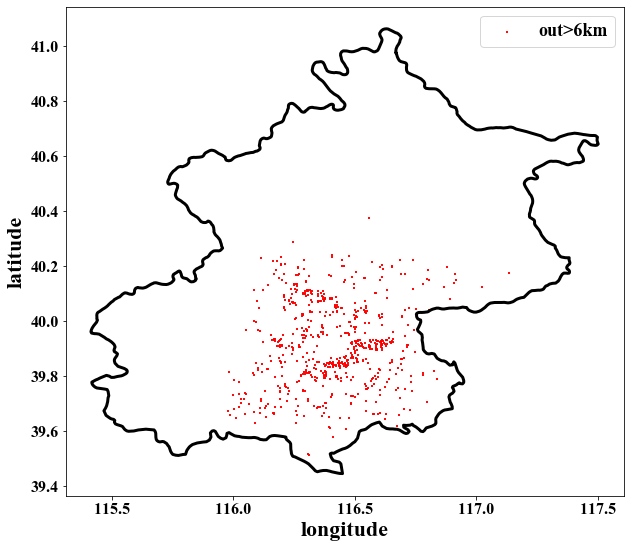

In [22]:
fig= plt.figure(figsize=(10,9))      
ax = fig.add_subplot(1,1,1) 
 
fig.set_facecolor('white')
plt.plot(bj_x,bj_y,color="black",linewidth="3")
ax.scatter(x1,y1,marker="s",s=1,label="out>6km",color='red')
#ax.scatter(ex,ey,marker="s",s=1)
#ax.scatter(ex,ey,alpha=1,label="无往返区域",color="yellow",marker="s",s=1)
#ax.scatter(sx1,sy1,alpha=0.1,label="往返区域",color="green",marker="s",s=1)
#ax.scatter(ex1,ey1,alpha=0.1,label="往返区域",color="green",marker="s",s=1)
plt.legend(loc="best",prop={'family':'Times New Roman','size':18})
#ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))#设置x主坐标间隔 1       
#ax.xaxis.set_minor_locator(plt.MultipleLocator(0.025))#设置x从坐标间隔 0.1    经度相差1度  距离随纬度变化
#ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))#设置y主坐标间隔 1
#ax.yaxis.set_minor_locator(plt.MultipleLocator(0.025))#设置y从坐标间隔 0.1    纬度相差1度是111公里
#ax.grid(which='major', axis='x', linewidth=0.75, linestyle='-', color='0.75')#由每个x主坐标出发对x主坐标画垂直于x轴的线段
#ax.grid(which='minor', axis='x', linewidth=0.25, linestyle='-', color='0.75')#由每个x主坐标出发对x主坐标画垂直于x轴的线段
#ax.grid(which='major', axis='y', linewidth=0.75, linestyle='-', color='0.75')
#ax.grid(which='minor', axis='y', linewidth=0.25, linestyle='-', color='0.75')
#plt.title("All starting points",fontsize=18)    #所有出发点
ax.set_xlabel("longitude",fontdict={'size'   : 22,"family":"Times New Roman"})#经度
ax.set_ylabel("latitude",fontdict={ 'size'   : 22,"family":"Times New Roman"})#纬度
#ax.scatter(cen_x,cen_y,color="black",s=30)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman')
plt.tick_params(labelsize=16)
#ax.set_xlim(120.8,122.1)
#ax.set_ylim(30.6,31.6)
#plt.savefig('500m出流加权出行距离小于5km空间分布.pdf')

In [29]:
x1=[]
y1=[]
l1=dt1_["loc1"].tolist()
for i in l1:
    r=df2[df2["Id"]==i]
    x=r.iloc[0]["x"]
    x1.append(x)
    y=r.iloc[0]["y"]
    y1.append(y)

In [30]:
dis1=[]
for i in range(len(x1)):
    x=x1[i]
    y=y1[i]
    d=round(get_distance_hav(y, x, cy, cx),2)   #lat纬度
    dis1.append(d)

In [35]:
dis1.sort()

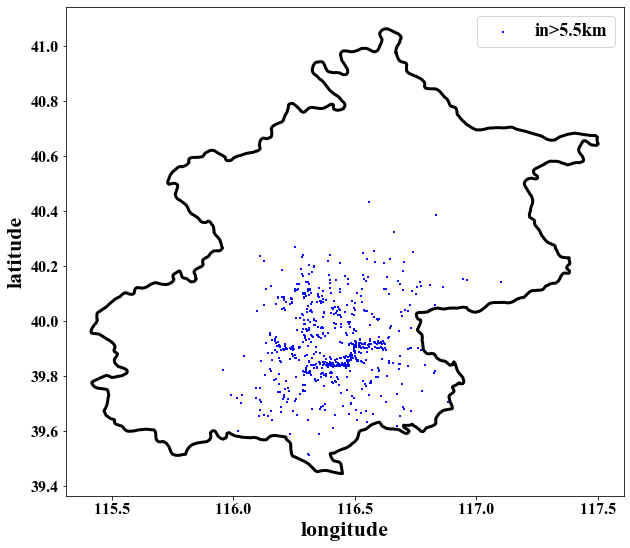

In [27]:
fig= plt.figure(figsize=(10,9))      
ax = fig.add_subplot(1,1,1) 
 
fig.set_facecolor('white')
plt.plot(bj_x,bj_y,color="black",linewidth="3")
ax.scatter(x1,y1,marker="s",s=1,label="in>5.5km",color='blue')
#ax.scatter(ex,ey,marker="s",s=1)
#ax.scatter(ex,ey,alpha=1,label="无往返区域",color="yellow",marker="s",s=1)
#ax.scatter(sx1,sy1,alpha=0.1,label="往返区域",color="green",marker="s",s=1)
#ax.scatter(ex1,ey1,alpha=0.1,label="往返区域",color="green",marker="s",s=1)
plt.legend(loc="best",prop={'family':'Times New Roman','size':18})
#ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))#设置x主坐标间隔 1       
#ax.xaxis.set_minor_locator(plt.MultipleLocator(0.025))#设置x从坐标间隔 0.1    经度相差1度  距离随纬度变化
#ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))#设置y主坐标间隔 1
#ax.yaxis.set_minor_locator(plt.MultipleLocator(0.025))#设置y从坐标间隔 0.1    纬度相差1度是111公里
#ax.grid(which='major', axis='x', linewidth=0.75, linestyle='-', color='0.75')#由每个x主坐标出发对x主坐标画垂直于x轴的线段
#ax.grid(which='minor', axis='x', linewidth=0.25, linestyle='-', color='0.75')#由每个x主坐标出发对x主坐标画垂直于x轴的线段
#ax.grid(which='major', axis='y', linewidth=0.75, linestyle='-', color='0.75')
#ax.grid(which='minor', axis='y', linewidth=0.25, linestyle='-', color='0.75')
#plt.title("All starting points",fontsize=18)    #所有出发点
ax.set_xlabel("longitude",fontdict={'size'   : 22,"family":"Times New Roman"})#经度
ax.set_ylabel("latitude",fontdict={ 'size'   : 22,"family":"Times New Roman"})#纬度
#ax.scatter(cen_x,cen_y,color="black",s=30)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman')
plt.tick_params(labelsize=16)
#ax.set_xlim(120.8,122.1)
#ax.set_ylim(30.6,31.6)
#plt.savefig('500m入流加权出行距离小于5km空间分布.pdf')
